# Занятие 5.
__1. Bagging__

__2. Случайный лес__

__3. XGBoost__

In [8]:
# Firstly import all required packages
# enable interactive mode of matplotlib
%matplotlib notebook

# import cv2  # python OpenCV
import os  # 
import numpy as np  # lib for arrays
import datetime
import glob
import pandas as pd

import math as mh  # math package

import matplotlib as mpl  
import matplotlib.pyplot as plt  # namespace for plotting
mpl.rcParams['figure.figsize'] = (6,5)  # change default value of plot size

# matplotlib based package for pretty visualization
import seaborn as sns
plt.style.use('seaborn')
from sklearn.datasets import load_iris

import time
import pickle  # package for dump & load data
import warnings

tips = sns.load_dataset("tips")

# <center> Bagging </center>

Рассмотрим следующий вопрос: можно ли из комбинации слабых моделей создать более сильную модель?

Ответ: да.

В общем случае техника комбинации более слабых моделей в более сильную называется [ансамблями](https://web.engr.oregonstate.edu/~tgd/publications/mcs-ensembles.pdf).

Предпосылкой создания ансамблей служил некоторый накопленный опыт:
* [Мудрость толпы](https://www.ozon.ru/context/detail/id/3352273/) (Wisdom of crowds):
    * В 1906 году британский ученый сэр Фрэнсис Гальтон посещал выставку достижений животноводства, где случайно провел крайне важное наблюдение. На выставке проводился конкурс, в рамках которого всем желающим предлагалось на глаз угадать точный вес забитого быка. Побеждал тот, кто называл самое близкое к истинному значение. Полагая, что справиться с подобной задачей под силу только профессионалу, и чтобы доказать некомпетентность толпы, Гальтон посчитал среднее значение из почти 800 догадок посетителей ярмарки. К удивлению ученого, толпа ошиблась меньше, чем на килограмм: точный вес быка 1198 фунтов, среднее значение толпы 1197 фунтов.
    * Новое и [неслучайное исследование](https://www.nature.com/articles/s41562-017-0247-6) "внутренней" мудрости толпы проводилось нидерландскими и британскими учёными в 2013-2015 г. Исследование проводилось в сети нидерландских казино каждый год в течение последних 7 предновогодних недель. Каждому посетителю было предложено угадать количество мелких предметов в большом бокале. Количество предметов в бокале было от 12 до 23 тысяч штук. По результату было получено 1,2 млн ответов. Данное исследование показало улучшение качества предсказаний с каждой последующей попыткой угадывания, но точность этих предсказаний улучшалась незначительно.   
* **Теорема Кондорсе "О жюри присяжных" (Condorcet Jury Theorem, 1784).** *Если каждый член жюри присяжных имеет независимое мнение, и если вероятность правильного решения члена жюри больше 0,5, то тогда вероятность правильногорешения присяжных в целом возрастает с увеличением количества членов жюри, и стремиться к единице. Еслиже вероятность быть правым у каждого из членов жюри меньше 0.5, то вероятность принятия правильногорешения присяжными в целом монотонно уменьшается истремится к нулю с увеличением количества присяжных.*

$$\LARGE \mu = \sum_{i=m}^{N}C_N^i p^i (1-p)^{N-i} $$

$ \mu $ - вероятность правильного решения всего жюри;

$ m = floor\left(\dfrac{N}{2} + 1\right) $ - минимальное большинство членов жюри;

$ N $ - число членов жюри;

$ p $ - вероятность правильного решения одного члена жюри;

Если $p>0,5$, то $\mu > p $, если $p<0,5$, то $\mu < p $.

Если $N \rightarrow \infty$ и $p < 0,5$, то $\mu \rightarrow 0$.

Если $N \rightarrow \infty$ и $p>0,5$, то $\mu \rightarrow 1$.

<table>
 <tr>
  <td>
   <img src="images/wisdom.jpg" height="350" width="350">
  </td>
  <td>
   <img src="images/bokal.jpg" height="350" width="350">
  </td>
  <td>
    <img src="images/judge.jpg" height="350" width="350">
  </td>
 </tr>
</table>

## <center> Bagging (Bootstrap aggregation) </center>

Наиболее распространённая техника ансамблирования моделей. *Bagging* был разработан [Лео Брейманом в 1994 году](https://www.stat.berkeley.edu/~breiman/bagging.pdf). Бэггинг основан на статистическом методе [**бутстрэпа (bootstrap)**](http://jeti.uni-freiburg.de/studenten_seminar/stud_sem_SS_09/EfronBootstrap.pdf), который позволяет оценивать многие статистики более сложных распределений.

Опишем технику *bootstrap*. Пусть датасет содержит $ N $ примеров: $\mathbf{X} = \{\mathbf{x_1}, \ldots, \mathbf{x_N}\}$. Создадим новый датасет $ \mathbf{X_B} $ с возвращением. Каждый пример в $ \mathbf{X_B} $ взят случайным образом из $\mathbf{X} $ с равной вероятностью $ \dfrac{1}{N}$. Повторим описанную процедуру $ M $ раз, то есть создадим $ M $ выборок: $ \mathbf{X_B^1}, \ldots, \mathbf{X_B^M} $. 

<img src="images/bootstrap.png"/> 

Применин технику бутстрэпа к обучающей выборке $ \mathbf{X} $ и сгенерируем выборки $ \mathbf{X_B^1}, \ldots, \mathbf{X_B^M} $. На каждой из созданных выборок обучим модель $a_i(x) $. Создадим модель $ a(x) $, которая будет усреднять предсказания каждой из обученной модели: 

$$ \LARGE a(x) = \dfrac{1}{M}\sum_{i=1}^{M} a_i(x) $$.

<img src="images/bagging.jpeg"/> 

Рассмотрим [пример регрессии](https://scikit-learn.org/stable/auto_examples/ensemble/plot_bias_variance.html#sphx-glr-auto-examples-ensemble-plot-bias-variance-py) из документации к Scikit-Learn. Для этого сгенерируем данные в виде функции: 

$$ \Large  f(x) = e^{-x^2} + 1,5 \cdot e^{-(x-2)^2} $$.

In [2]:
def f(x):
    x = x.ravel()
    return np.exp(-x ** 2) + 1.5 * np.exp(-(x - 2) ** 2)

Установим параметры генерируемых данных:
* `n_repeat` - число итераций для расчета мат. ожиданий
* `n_train` - размер обучающей выборки
* `n_test` - размер тестовой выборки
* `noise` - стандартного отклонение шума
* `random_seed` - состояние генератора случайных чисел

In [23]:
# Settings
n_repeat = 50       # Number of iterations for computing expectations
n_train = 50        # Size of the training set
n_test = 1000       # Size of the test set
noise = 0.1         # Standard deviation of the noise
random_seed = 0

Создадим функцию, которая будет генерировать искомую функцию с заданными параметрами.

In [3]:
def generate(n_samples, noise, n_repeat=1):
    X = np.random.rand(n_samples) * 10 - 5
    X = np.sort(X)

    if n_repeat == 1:
        y = f(X) + np.random.normal(0.0, noise, n_samples)
    else:
        y = np.zeros((n_samples, n_repeat))

        for i in range(n_repeat):
            y[:, i] = f(X) + np.random.normal(0.0, noise, n_samples)

    X = X.reshape((n_samples, 1))

    return X, y

Импортируем `DecisionTreeRegressor`, `BaggingRegressor` и `LinearRegression`.

In [18]:
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor

<IPython.core.display.Javascript object>


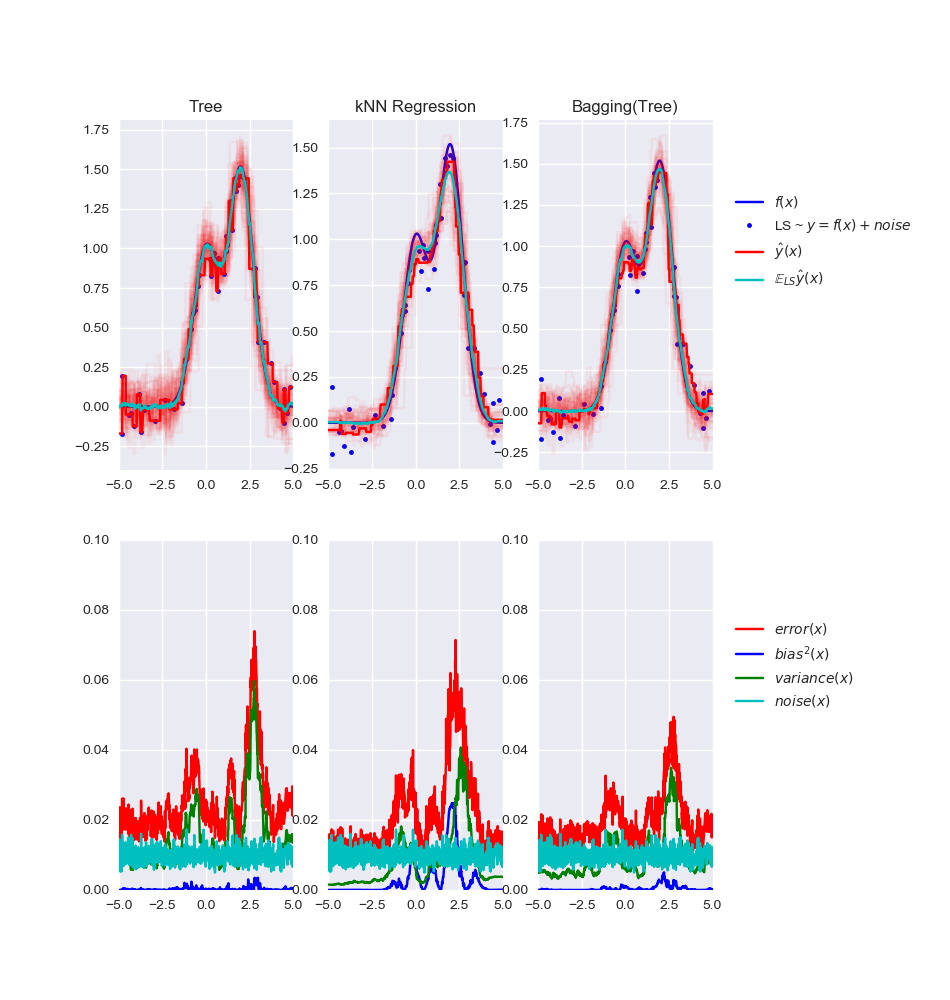

Tree: 0.0255 (error) = 0.0003 (bias^2)  + 0.0152 (var) + 0.0098 (noise)
kNN Regression: 0.0210 (error) = 0.0028 (bias^2)  + 0.0082 (var) + 0.0098 (noise)
Bagging(Tree): 0.0196 (error) = 0.0004 (bias^2)  + 0.0092 (var) + 0.0098 (noise)


In [22]:
# Change this for exploring the bias-variance decomposition of other
# estimators. This should work well for estimators with high variance (e.g.,
# decision trees or KNN), but poorly for estimators with low variance (e.g.,
# linear models).
np.random.seed(random_seed)
estimators = [("Tree", DecisionTreeRegressor()),
              ("kNN Regression", KNeighborsRegressor()),
              ("Bagging(Tree)", BaggingRegressor(DecisionTreeRegressor()))]

n_estimators = len(estimators)

X_train = []
y_train = []

for i in range(n_repeat):
    X, y = generate(n_samples=n_train, noise=noise)
    X_train.append(X)
    y_train.append(y)

X_test, y_test = generate(n_samples=n_test, noise=noise, n_repeat=n_repeat)

plt.figure(figsize=(9.5, 10))

# Loop over estimators to compare
for n, (name, estimator) in enumerate(estimators):
    # Compute predictions
    y_predict = np.zeros((n_test, n_repeat))

    for i in range(n_repeat):
        estimator.fit(X_train[i], y_train[i])
        y_predict[:, i] = estimator.predict(X_test)

    # Bias^2 + Variance + Noise decomposition of the mean squared error
    y_error = np.zeros(n_test)

    for i in range(n_repeat):
        for j in range(n_repeat):
            y_error += (y_test[:, j] - y_predict[:, i]) ** 2

    y_error /= (n_repeat * n_repeat)

    y_noise = np.var(y_test, axis=1)
    y_bias = (f(X_test) - np.mean(y_predict, axis=1)) ** 2
    y_var = np.var(y_predict, axis=1)

    print("{0}: {1:.4f} (error) = {2:.4f} (bias^2) "
          " + {3:.4f} (var) + {4:.4f} (noise)".format(name,
                                                      np.mean(y_error),
                                                      np.mean(y_bias),
                                                      np.mean(y_var),
                                                      np.mean(y_noise)))

    # Plot figures
    plt.subplot(2, n_estimators, n + 1)
    plt.plot(X_test, f(X_test), "b", label="$f(x)$")
    plt.plot(X_train[0], y_train[0], ".b", label="LS ~ $y = f(x)+noise$")

    for i in range(n_repeat):
        if i == 0:
            plt.plot(X_test, y_predict[:, i], "r", label=r"$\^y(x)$")
        else:
            plt.plot(X_test, y_predict[:, i], "r", alpha=0.05)

    plt.plot(X_test, np.mean(y_predict, axis=1), "c",
             label=r"$\mathbb{E}_{LS} \^y(x)$")

    plt.xlim([-5, 5])
    plt.title(name)

    if n == n_estimators - 1:
        plt.legend(loc=(1.1, .5))

    plt.subplot(2, n_estimators, n_estimators + n + 1)
    plt.plot(X_test, y_error, "r", label="$error(x)$")
    plt.plot(X_test, y_bias, "b", label="$bias^2(x)$"),
    plt.plot(X_test, y_var, "g", label="$variance(x)$"),
    plt.plot(X_test, y_noise, "c", label="$noise(x)$")

    plt.xlim([-5, 5])
    plt.ylim([0, 0.1])

    if n == n_estimators - 1:

        plt.legend(loc=(1.1, .5))

plt.subplots_adjust(right=.75)

Итоговое выражение показывает плюсы использования бэггинга. 

Давайте рассмотрим более подробно выражение для регрессии. Запишем ошибку каждой из модели $ b_i(x) $:

$$ \LARGE \varepsilon_i = b_i(x) - y(x), \, i=1\ldots n $$.

Найдем мат. ожидание MSE:

$$ \LARGE \mathbb{E_x}(b_i(x) - y_i)^2 = \mathbb{E_x} \varepsilon_i(x)^2 $$.

Тогда средняя ошибка моделей $ b_i(x) $ имеет вид:

$$\LARGE E_{model} = \dfrac{1}{n} \mathbb{E_x}\sum_{i=1}^{n} \varepsilon^2_i(x) $$.

Ошибки являются несмещёнными и нескореллированными:

$$ \large \mathbb{E}_x\varepsilon_i(x) = 0 $$

$$ \large \mathbb{E_x}\varepsilon_i(x)\varepsilon_j(x) = 0, i \neq j $$

Построим модель регрессора, которая усредняет предсказания каждой из отдельных моделей:

$$ \large a(x) = \dfrac{1}{n} \sum_{i=1}^{n} b_i(x) $$

и найдем её MSE:

$$ \large E_n = \left(\dfrac{1}{n} \sum_{i=1}^{n} b_i(x) - y(x)\right)^2 = \mathbb{E}_x\left( \dfrac{1}{n} \sum_{i=1}^{n} \varepsilon_i \right)^2 = \dfrac{1}{n^2} \mathbb{E}_x \left( \sum_{i=1}^{n} \varepsilon^2_i(x) + \sum_{i \neq j} \varepsilon_i(x)\varepsilon_j(x) \right) =  \dfrac{1}{n} E_{model} $$.

Таким образом, использование бэггинга позволило уменьшить MSE в $n$ раз. Ошибка MSE соответствует компоненте разброса $ Var $  в разложении ошибки:

$$\Huge Err(\overrightarrow{x}) = Bias\left(\hat{f}\right)^2 + Var\left(\hat{f}\right) + \sigma^2$$



# <center> Случайный лес </center>

Плюсы:
* Обладает хорошим качеством
* Не чувствителен к выбросам
* Отсутствие требований к предобработке данных
* Out-of-bag ошибка
* Небольшая чувствительность к гиперпараметрам, то есть даёт качественный результат прямо из коробки.


Минусы:
* Не позволяет качественно интерпретировать зависимости

# <center> Деревья решений </center>

__Дерево решений__ – это модель, представляющая собой совокупность правил для принятия решений.

Графически её можно представить в виде древовидной структуры, где моменты принятия решений соответствуют так называемым узлам (_decision  nodes_). В узлах происходит ветвление процесса (_branching_), т.е.  деление его на так называемые ветви (_branches_) в зависимости от сделанного выбора. Конечные (или, что то же самое, терминальные) узлы называют листьями (_leafs, leafnodes_), где каждый лист – это конечный результат последовательного принятия решений.

Построение дерева основано на приросте информации в каждом узле, т.е. уменьшении энтропии Шеннона:

$$ S=-\sum_{i}^{N}{p_i\,log_2 p_i} $$

Уменьшение энтропии при разбиении по признаку _Q_ оценивается с помощью прироста информации (Information Gain - IG):

$$ IG(Q) = S_{0} - \sum_{i=1}^{q}\dfrac{N_i}{N} S_{i} $$

[Официальная документация Scikit-Learn Decision Trees](https://scikit-learn.org/stable/modules/tree.html)